## Setup

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

project_id = "walmart-demand-intelligence"
client     = bigquery.Client(project=project_id)

print("Connected!")

Connected!


In [ ]:
# Start with one category at one store for development
df = client.query("""
    SELECT
        item_id,
        store_id,
        day_num,
        calendar_date,
        sales,
        is_no_sales,
        lag_1,
        lag_7,
        rolling_mean_7,
        rolling_mean_28,
    FROM `walmart_forecasting.mart_forecast_input`
    WHERE store_id  = 'CA_1'
    AND   category  = 'FOODS'
    AND   calendar_date IS NOT NULL
    ORDER BY item_id, day_num
""").to_dataframe()

df['calendar_date'] = pd.to_datetime(df['calendar_date'])

print(f"Rows:        {len(df):,}")
print(f"Items:       {df['item_id'].nunique():,}")
print(f"Date range:  {df['calendar_date'].min().date()} → {df['calendar_date'].max().date()}")
print(f"Total days:  {df['day_num'].max()}")

Rows:        2,789,217
Items:       1,437
Date range:  2011-01-29 → 2016-05-22
Total days:  1941


# Build baseline forecast for store CA_1
1. Baseline 1: Last value           predict today = yesterday
    - "Tomorrow's sales = today's sales"
2. Baseline 2: Seasonal naive       predict today = same day last week
    - "Tomorrow's sales = same day last week"
3. Baseline 3: Rolling mean         predict today = 28-day average
    - "Tomorrow's sales = average of last 28 days"

## Reason to build baseline
- Want baseline that can compare with the actual forecast model
- Normally we can compare with just random guessing (prob 0.5), but with these basic forecast with some logic is better
- If start with buiding complex deep learning, get the evaluation metric but don't know is it good
- Use this when there are no existing model to compare, if previous models exist, use them to compare


## Define Train and Test data

In [5]:
FORECAST_HORIZON = 28
TRAIN_CUTOFF     = df['day_num'].max() - FORECAST_HORIZON

df_train = df[df['day_num'] <= TRAIN_CUTOFF].copy()
df_test  = df[df['day_num'] >  TRAIN_CUTOFF].copy()

print(f"Train period: day 1     to day {TRAIN_CUTOFF}")
print(f"Test period:  day {TRAIN_CUTOFF+1}  to day {df['day_num'].max()}")
print(f"Train rows:   {len(df_train):,}")
print(f"Test rows:    {len(df_test):,}")
print(f"Items:        {df['item_id'].nunique():,}")

Train period: day 1     to day 1913
Test period:  day 1914  to day 1941
Train rows:   2,748,981
Test rows:    40,236
Items:        1,437


## Cretae evaluation metric with RMSSE

### Reason to use Root Mean Squared Scaled Error (RMSSE)
M5 has 30,490 items across:
- 3 categories (FOODS, HOBBIES, HOUSEHOLD)
- 10 stores
- Very different sales volumes

Without scaling:
- FOODS items dominate the metric (they sell more, bigger absolute errors)
- Model optimizes for high-volume items only
- Ignores low-volume items completely

With RMSSE:
- Every item weighted fairly
- Low-volume items matter as much as high-volume
- More realistic business metric

In [6]:
def rmsse(actual, predicted, train_series):
    """
    Root Mean Squared Scaled Error
    M5 competition standard metric
    Lower is better — 1.0 = same as naive forecast
    """
    mse          = np.mean((actual - predicted) ** 2)
    naive_errors = np.diff(train_series)
    scaling      = np.mean(naive_errors ** 2)

    if scaling == 0:
        return np.nan

    return np.sqrt(mse / scaling)


def evaluate_all_items(df_test, pred_col, df_train):
    """Calculate RMSSE per item and return summary"""
    results = []

    for item_id in df_test['item_id'].unique():
        actual    = df_test[df_test['item_id']==item_id]['sales'].values
        predicted = df_test[df_test['item_id']==item_id][pred_col].values
        train     = df_train[df_train['item_id']==item_id]['sales'].values

        score = rmsse(actual, predicted, train)
        results.append({
            'item_id': item_id,
            'rmsse':   score
        })

    return pd.DataFrame(results)

print("RMSSE functions defined")
print()
print("Interpretation:")
print("  RMSSE < 1.0: better than naive forecast")
print("  RMSSE = 1.0: same as naive forecast")
print("  RMSSE > 1.0: worse than naive forecast")

RMSSE functions defined

Interpretation:
  RMSSE < 1.0: better than naive forecast
  RMSSE = 1.0: same as naive forecast
  RMSSE > 1.0: worse than naive forecast


## Baseline 1: Last value (lag_1)

In [7]:
df_test_b1 = df_test.copy()
df_test_b1['pred_last_value'] = df_test_b1['lag_1'].fillna(0)

results_b1 = evaluate_all_items(df_test_b1, 'pred_last_value', df_train)
rmsse_b1   = results_b1['rmsse'].median()

print(f"Baseline 1 — Last Value (lag_1)")
print(f"  Median RMSSE: {rmsse_b1:.4f}")
print(f"  Mean RMSSE:   {results_b1['rmsse'].mean():.4f}")
print(f"  Items scored: {results_b1['rmsse'].notna().sum():,}")

Baseline 1 — Last Value (lag_1)
  Median RMSSE: 1.0650
  Mean RMSSE:   1.1721
  Items scored: 1,437


## Baseline 2: Seasonal naive (lag_7)

In [8]:
df_test_b2 = df_test.copy()
df_test_b2['pred_seasonal'] = df_test_b2['lag_7'].fillna(0)

results_b2 = evaluate_all_items(df_test_b2, 'pred_seasonal', df_train)
rmsse_b2   = results_b2['rmsse'].median()

print(f"Baseline 2 — Seasonal Naive (lag_7)")
print(f"  Median RMSSE: {rmsse_b2:.4f}")
print(f"  Mean RMSSE:   {results_b2['rmsse'].mean():.4f}")
print(f"  Items scored: {results_b2['rmsse'].notna().sum():,}")

Baseline 2 — Seasonal Naive (lag_7)
  Median RMSSE: 1.0688
  Mean RMSSE:   1.1774
  Items scored: 1,437


## Baseline 3: Rolling mean (lag_28)

In [9]:
df_test_b3 = df_test.copy()
df_test_b3['pred_rolling'] = df_test_b3['rolling_mean_28'].fillna(0)

results_b3 = evaluate_all_items(df_test_b3, 'pred_rolling', df_train)
rmsse_b3   = results_b3['rmsse'].median()

print(f"Baseline 3 — Rolling Mean (28 days)")
print(f"  Median RMSSE: {rmsse_b3:.4f}")
print(f"  Mean RMSSE:   {results_b3['rmsse'].mean():.4f}")
print(f"  Items scored: {results_b3['rmsse'].notna().sum():,}")

Baseline 3 — Rolling Mean (28 days)
  Median RMSSE: 0.8061
  Mean RMSSE:   0.8926
  Items scored: 1,437


## Compare all baselines

BASELINE COMPARISON
       Baseline  Median RMSSE  Mean RMSSE
     Last Value        1.0650      1.1721
 Seasonal Naive        1.0688      1.1774
Rolling Mean 28        0.8061      0.8926

 Best baseline: Rolling Mean 28
 Best RMSSE: 0.8061


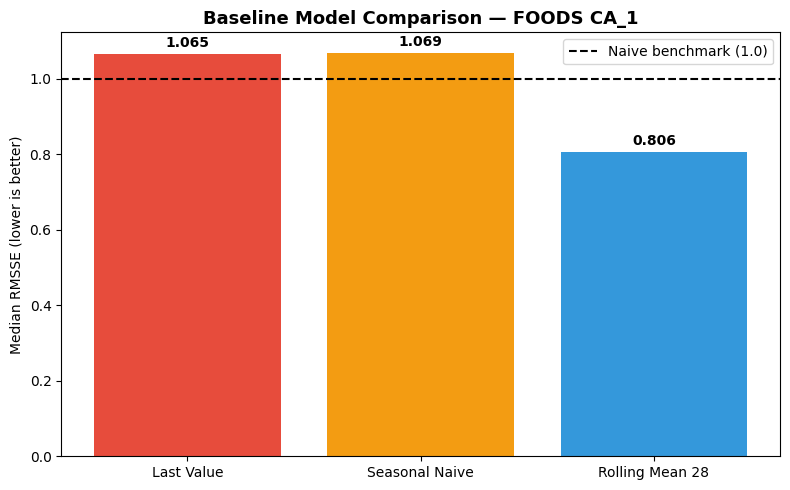

In [11]:
comparison = pd.DataFrame({
    'Baseline':     ['Last Value', 'Seasonal Naive', 'Rolling Mean 28'],
    'Median RMSSE': [rmsse_b1, rmsse_b2, rmsse_b3],
    'Mean RMSSE':   [
        results_b1['rmsse'].mean(),
        results_b2['rmsse'].mean(),
        results_b3['rmsse'].mean()
    ]
}).round(4)

best = comparison.loc[comparison['Median RMSSE'].idxmin(), 'Baseline']

print("=" * 50)
print("BASELINE COMPARISON")
print("=" * 50)
print(comparison.to_string(index=False))
print()
print(f" Best baseline: {best}")
print(f" Best RMSSE: {comparison['Median RMSSE'].min():.4f}")

# Plot
plt.figure(figsize=(8, 5))
colors = ['#e74c3c', '#f39c12', '#3498db']
bars   = plt.bar(comparison['Baseline'],
                  comparison['Median RMSSE'],
                  color=colors)
plt.axhline(y=1.0, color='black', linestyle='--',
            label='Naive benchmark (1.0)')
plt.title('Baseline Model Comparison — FOODS CA_1',
           fontsize=13, fontweight='bold')
plt.ylabel('Median RMSSE (lower is better)')
plt.legend()

for bar, val in zip(bars, comparison['Median RMSSE']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom',
             fontweight='bold')

plt.tight_layout()
plt.savefig('../dashboard/baseline_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

## Visualize forecast for one item

Visualizing: FOODS_3_090


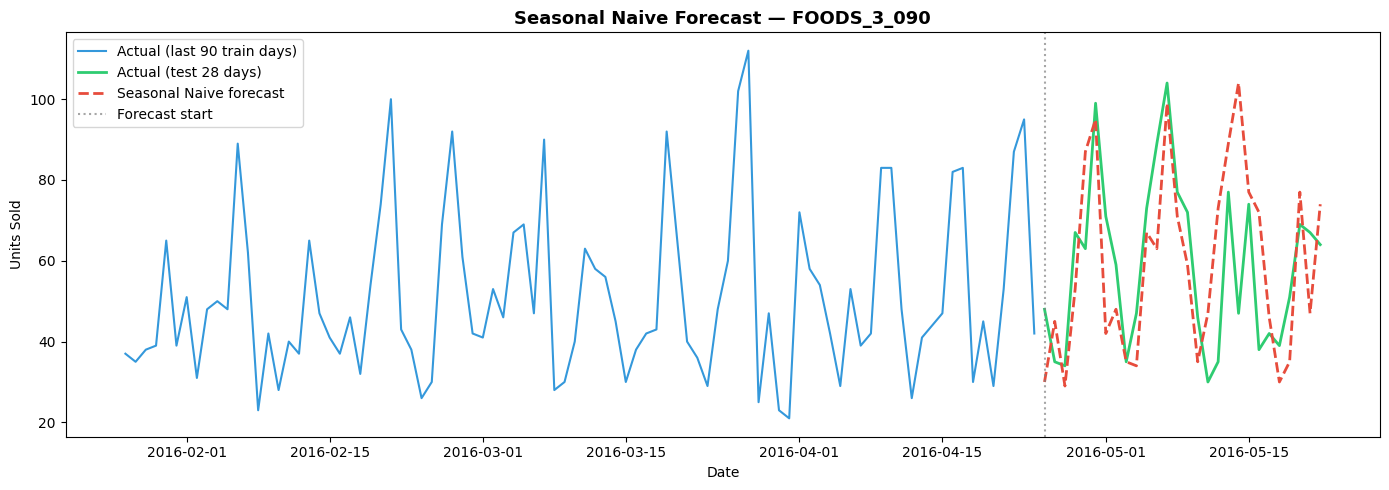

In [13]:
# Pick highest selling item for clearest visualization
sample_item = (
    df_train.groupby('item_id')['sales']
    .sum()
    .sort_values(ascending=False)
    .index[0]
)
print(f"Visualizing: {sample_item}")

train_item = df_train[df_train['item_id']==sample_item]
test_item  = df_test_b2[df_test_b2['item_id']==sample_item]

plt.figure(figsize=(14, 5))

plt.plot(train_item['calendar_date'].tail(90),
         train_item['sales'].tail(90),
         color='#3498db', linewidth=1.5,
         label='Actual (last 90 train days)')

plt.plot(test_item['calendar_date'],
         test_item['sales'],
         color='#2ecc71', linewidth=2,
         label='Actual (test 28 days)')

plt.plot(test_item['calendar_date'],
         test_item['pred_seasonal'],
         color='#e74c3c', linewidth=2,
         linestyle='--', label='Seasonal Naive forecast')

plt.axvline(x=test_item['calendar_date'].min(),
            color='gray', linestyle=':',
            alpha=0.7, label='Forecast start')
plt.title(f'Seasonal Naive Forecast — {sample_item}',
           fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Units Sold')
plt.legend()
plt.tight_layout()
plt.savefig('../dashboard/baseline_forecast_sample.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Summary

## Baseline Forecast — Key Results

### RMSSE Scores (FOODS category, CA_1 store)

| Baseline | Median RMSSE | Interpretation |
|----------|-------------|----------------|
| Last Value | 1.0650 | daily sales too noisy (If yesterday = 0, predict 0 forever) |
| Seasonal Naive (lag_7) | 1.0688 | weekly pattern not strong enough alone (lag_7 is often 0) |
| Rolling Mean 28 | 0.8061 | smoothing reduces noise from 63.8% zero days |

### Key Observations
- 63.8% zero sales days is the core challenge
- Simple lag features fail on sparse demand data
- Smoothing (28-day average) beats point-in-time lags
- Both lag baselines worse than naive (RMSSE > 1.0), raw lag features need ML to extract signal

### Target
Beat best baseline RMSSE of 0.8061
Top 20% M5 leaderboard: RMSSE < 0.60